In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap
from openpyxl.styles.numbers import COLORS

from source.fuse_dual_tomograms import segment_backround_otsu

# =============================================================
# ANATOMICAL MEASUREMENTS FROM EXCEL
# =============================================================
# Path hardcoded al file Excel
EXCEL_PATH = '/home/fra/Pycharm_Projects/whole_heart/data/Correlation_wallthickness_fibrosis.xlsx'

# Carica lo sheet "medie_fra_campioni" dal file Excel
wall_thickness = pd.read_excel(EXCEL_PATH, sheet_name='wall_thickness_um_x_segment', skiprows=1, index_col=0)
print("wall_thickness:\n", wall_thickness)


print("wall_thickness:\n", wall_thickness)
print("\n\n *** wall_thickness columns:", wall_thickness.columns.tolist())
# =============================================================

# inserisci i valori di CTRL (seconda riga) in un dizionario dove la chiave è l'angolo e il valore è il valore di wall_thickness
CTRL_wall_thickness_um = wall_thickness.iloc[0].to_dict()
print("\n\n *** CTRL_wall_thickness_um:", CTRL_wall_thickness_um)
# inserisci i valori di PATHOL (terza riga) in un dizionario dove la chiave è l'angolo e il valore è il valore di wall_thickness
PATHOL_wall_thickness_um = wall_thickness.iloc[1].to_dict()
print("\n\n *** PATHOL_wall_thickness_um:", PATHOL_wall_thickness_um)

wall_thickness:
                 0            60           120          180          240  \
CTRL    1577.270667  1391.490444  1471.514889  1454.143667  1454.366556   
PATHOL  1463.123556  1681.267444  1286.113778  1071.480222  1367.618333   

                300  
CTRL    1652.636556  
PATHOL  1572.449444  
wall_thickness:
                 0            60           120          180          240  \
CTRL    1577.270667  1391.490444  1471.514889  1454.143667  1454.366556   
PATHOL  1463.123556  1681.267444  1286.113778  1071.480222  1367.618333   

                300  
CTRL    1652.636556  
PATHOL  1572.449444  


 *** wall_thickness columns: [0, 60, 120, 180, 240, 300]


 *** CTRL_wall_thickness_um: {0: 1577.2706666666666, 60: 1391.4904444444446, 120: 1471.514888888889, 180: 1454.1436666666666, 240: 1454.3665555555554, 300: 1652.6365555555556}


 *** PATHOL_wall_thickness_um: {0: 1463.1235555555554, 60: 1681.2674444444444, 120: 1286.1137777777778, 180: 1071.480222222222, 240: 1367.61833

In [16]:

# =============================================================
# LOAD DATAFRAMES OF AMOUNT OF COLLAGEN FROM PICKLE FILES
# =============================================================

# load dataframes from these paths:
CTRL_perc_CF_path = '/home/fra/Pycharm_Projects/whole_heart/data/average_dict_radii_theta/CTRL_perc_CF.pkl'
CTRL_perc_NCF_path = '/home/fra/Pycharm_Projects/whole_heart/data/average_dict_radii_theta/CTRL_perc_NCF.pkl'
PATHOL_perc_CF_path = '/home/fra/Pycharm_Projects/whole_heart/data/average_dict_radii_theta/PATHOL_perc_CF.pkl'
PATHOL_perc_NCF_path = '/home/fra/Pycharm_Projects/whole_heart/data/average_dict_radii_theta/PATHOL_perc_NCF.pkl'

# load the dataframes using pickle
CTRL_perc_CF = pd.read_pickle(CTRL_perc_CF_path)
CTRL_perc_NCF = pd.read_pickle(CTRL_perc_NCF_path)
PATHOL_perc_CF = pd.read_pickle(PATHOL_perc_CF_path)
PATHOL_perc_NCF = pd.read_pickle(PATHOL_perc_NCF_path)

# print the dataframes
print("CTRL_perc_CF:\n", CTRL_perc_CF)
print("CTRL_perc_NCF:\n", CTRL_perc_NCF)
print("PATHOL_perc_CF:\n", PATHOL_perc_CF)
print("PATHOL_perc_NCF:\n", PATHOL_perc_NCF)

CTRL_perc_CF:
                  0         22        45        67        90        112  \
15.738889   0.070876  0.164143  0.083086  0.027117  0.199457  0.084349   
31.477778   0.042258  0.022942  0.160990  0.365609  0.222336  0.097216   
47.216667   0.099564  0.117967  0.129612  0.137467  0.049417  0.106270   
62.955556   0.100467  0.082718  0.147170  0.103123  0.144138  0.106409   
78.694444   0.052098  0.182597  0.237989  0.215996  0.357597  0.083540   
94.433333   0.146045  0.112988  0.315649  0.201969  0.699925  0.253449   
110.172222  0.174755  0.062141  0.152645  1.159764  0.410136  0.314987   
125.911111  0.183424  0.087297  0.171884  0.204471  0.412580  0.236575   
141.650000  0.133962  0.164321  0.401629  0.432804  0.601844  0.230824   
157.388889  0.187473  0.690030  0.823441  0.596526  0.894376  0.337527   
173.127778  0.451940  0.618004  0.469439  0.425681  0.509795  0.357901   
188.866667  0.441598  0.728765  0.190160  0.203984  0.248309  0.194268   
204.605556  0.613066  1

In [18]:


# somma CTRL_perc_CF and CTRL_perc_NCF
CTRL_perc_fibrosis = CTRL_perc_CF + CTRL_perc_NCF
# somma PATHOL_perc_CF and PATHOL_perc_NCF
PATHOL_perc_fibrosis = PATHOL_perc_CF + PATHOL_perc_NCF

# save as excel files
CTRL_perc_fibrosis.to_excel('/home/fra/Pycharm_Projects/whole_heart/data/CTRL_perc_total_fibrosis.xlsx')
PATHOL_perc_fibrosis.to_excel('/home/fra/Pycharm_Projects/whole_heart/data/PATHOL_perc_total_fibrosis.xlsx')

# SOMMA PER TUTTI I RAGGI
# somma le colonne di CTRL_perc_fibrosis
CTRL_perc_fibrosis_sum = CTRL_perc_fibrosis.sum(axis=0)
# somma le colonne di PATHOL_perc_fibrosis
PATHOL_perc_fibrosis_sum = PATHOL_perc_fibrosis.sum(axis=0)

# save as excel files
CTRL_perc_fibrosis_sum.to_excel('/home/fra/Pycharm_Projects/whole_heart/data/CTRL_perc_total_fibrosis_sum_on_radii.xlsx')
PATHOL_perc_fibrosis_sum.to_excel('/home/fra/Pycharm_Projects/whole_heart/data/PATHOL_perc_total_fibrosis_sum_sum_on_radii.xlsx')
# =============================================================

# Print the results

print("\n\n *** wall_thickness:", wall_thickness)
print("\n\n *** CTRL_perc_fibrosis_sum:", CTRL_perc_fibrosis_sum)
print("\n\n *** PATHOL_perc_fibrosis_sum:", PATHOL_perc_fibrosis_sum)


#===========================================================
# stampa i nomi delle colonne di CTRL_perc_fibrosis_sum
print("\n\n *** CTRL_perc_fibrosis_sum columns:", CTRL_perc_fibrosis_sum.index.tolist())


# converti CTRL_perc_fibrosis_sum in un dizionario
CTRL_perc_fibrosis_sum_dict = CTRL_perc_fibrosis_sum.to_dict()
print("\n\n *** CTRL_perc_fibrosis_sum_dict:", CTRL_perc_fibrosis_sum_dict)
# converti PATHOL_perc_fibrosis_sum in un dizionario
PATHOL_perc_fibrosis_sum_dict = PATHOL_perc_fibrosis_sum.to_dict()
print("\n\n *** PATHOL_perc_fibrosis_sum_dict:", PATHOL_perc_fibrosis_sum_dict)





 *** wall_thickness:                 0            60           120          180          240  \
CTRL    1577.270667  1391.490444  1471.514889  1454.143667  1454.366556   
PATHOL  1463.123556  1681.267444  1286.113778  1071.480222  1367.618333   

                300  
CTRL    1652.636556  
PATHOL  1572.449444  


 *** CTRL_perc_fibrosis_sum: 0      17.617775
22     29.999517
45     27.968477
67     27.867371
90     25.549905
112    17.577173
135    29.751468
157    41.164604
180    42.936376
202    44.030140
225    27.872479
247    22.156798
270    24.005390
292    18.166567
315    24.063934
337    24.576199
dtype: float64


 *** PATHOL_perc_fibrosis_sum: 0       66.788274
22      85.103886
45      71.188860
67      37.789659
90      60.561078
112     74.969368
135     69.519964
157     34.146524
180     23.357716
202     67.627291
225     59.707082
247     80.113648
270    247.006559
292    191.479175
315     84.589851
337     51.049925
dtype: float64


 *** CTRL_perc_fibrosis_sum c

In [21]:
# da qui in poi uso solo i dizionari  CTRL_wall_thickness_um, PATHOL_wall_thickness_um, CTRL_perc_fibrosis_sum_dict, PATHOL_perc_fibrosis_sum_dict
# STAMPA IL CONTENUTO DI CTRL_wall_thickness_um E PATHOL_wall_thickness_um PER OGNI CHIAVE
# itera su CTRL_wall_thickness_um.keys e stampa i valori corrispondenti in CTRL_wall_thickness_um e PATHOL_wall_thickness_um
for key in CTRL_wall_thickness_um.keys():
    print(f"CTRL_wall_thickness_um[{key}]: {CTRL_wall_thickness_um[key]} um, "
          f"PATHOL_wall_thickness_um[{key}]: {PATHOL_wall_thickness_um[key]} um")
    
# itera sulle chiavi di CTRL_perc_fibrosis_sum_dict e stampa i valori corrispondenti in CTRL_perc_fibrosis_sum_dict e PATHOL_perc_fibrosis_sum_dict
print(" \n\n AMOUNT OF COLLAGEN IN PERC")
for key in CTRL_perc_fibrosis_sum_dict.keys():
    print(f"CTRL_perc_fibrosis_sum_dict[{key}]: {CTRL_perc_fibrosis_sum_dict[key]} %, "
          f"PATHOL_perc_fibrosis_sum_dict[{key}]: {PATHOL_perc_fibrosis_sum_dict[key]} %")

CTRL_wall_thickness_um[0]: 1577.2706666666666 um, PATHOL_wall_thickness_um[0]: 1463.1235555555554 um
CTRL_wall_thickness_um[60]: 1391.4904444444446 um, PATHOL_wall_thickness_um[60]: 1681.2674444444444 um
CTRL_wall_thickness_um[120]: 1471.514888888889 um, PATHOL_wall_thickness_um[120]: 1286.1137777777778 um
CTRL_wall_thickness_um[180]: 1454.1436666666666 um, PATHOL_wall_thickness_um[180]: 1071.480222222222 um
CTRL_wall_thickness_um[240]: 1454.3665555555554 um, PATHOL_wall_thickness_um[240]: 1367.618333333333 um
CTRL_wall_thickness_um[300]: 1652.6365555555556 um, PATHOL_wall_thickness_um[300]: 1572.4494444444445 um
 

 AMOUNT OF COLLAGEN IN PERC
CTRL_perc_fibrosis_sum_dict[0]: 17.61777488624849 %, PATHOL_perc_fibrosis_sum_dict[0]: 66.7882738022343 %
CTRL_perc_fibrosis_sum_dict[22]: 29.999517034709847 %, PATHOL_perc_fibrosis_sum_dict[22]: 85.10388648864512 %
CTRL_perc_fibrosis_sum_dict[45]: 27.96847669245759 %, PATHOL_perc_fibrosis_sum_dict[45]: 71.1888604033837 %
CTRL_perc_fibrosis_sum_d

In [22]:
def interpolate_wall_thickness(ctrl_wall_thickness, new_keys):
    """
    Interpola i valori di CTRL_wall_thickness_um per le nuove chiavi.

    Args:
        ctrl_wall_thickness (dict): Dizionario con chiavi e valori originali di wall thickness.
        new_keys (list): Nuove chiavi per cui interpolare i valori.

    Returns:
        dict: Dizionario con le nuove chiavi e i valori interpolati.
    """
    # Estrai chiavi e valori originali
    original_keys = np.array(list(ctrl_wall_thickness.keys()))
    original_values = np.array(list(ctrl_wall_thickness.values()))

    # Interpola i valori per le nuove chiavi
    interpolated_values = np.interp(new_keys, original_keys, original_values)

    # Crea il nuovo dizionario
    interpolated_dict = {key: value for key, value in zip(new_keys, interpolated_values)}

    return interpolated_dict

In [23]:
# Interpolazione dei valori di wall thickness per le chiavi di CTRL_perc_fibrosis_sum_dict
new_keys = list(CTRL_perc_fibrosis_sum_dict.keys())
CTRL_wall_thickness_interp = interpolate_wall_thickness(CTRL_wall_thickness_um, new_keys)
PATHOL_wall_thickness_interp = interpolate_wall_thickness(PATHOL_wall_thickness_um, new_keys)
# Stampa i risultati dell'interpolazione
print("\n\n *** CTRL_wall_thickness_interp:", CTRL_wall_thickness_interp)
print("\n\n *** PATHOL_wall_thickness_interp:", PATHOL_wall_thickness_interp)



 *** CTRL_wall_thickness_interp: {0: 1577.2706666666666, 22: 1509.1512518518518, 45: 1437.9355, 67: 1400.8266296296297, 90: 1431.5026666666668, 112: 1460.8449629629629, 135: 1467.1720833333334, 157: 1460.8026351851852, 180: 1454.1436666666666, 202: 1454.2253925925925, 225: 1454.3108333333332, 247: 1477.4980555555553, 270: 1553.5015555555556, 292: 1626.2005555555556, 315: 1652.6365555555556, 337: 1652.6365555555556}


 *** PATHOL_wall_thickness_interp: {0: 1463.1235555555554, 22: 1543.1096481481482, 45: 1626.7314722222222, 67: 1635.1661833333333, 90: 1483.6906111111111, 112: 1338.8009333333334, 135: 1232.4553888888888, 157: 1153.7564185185183, 180: 1071.480222222222, 202: 1180.0641962962961, 225: 1293.5838055555553, 247: 1391.5152962962961, 270: 1470.0338888888887, 292: 1545.1386296296296, 315: 1572.4494444444445, 337: 1572.4494444444445}


In [24]:
def plot_wall_thickness_vs_collagen(wall_thickness, collagen_percentage, title="Correlazione Wall Thickness vs Collagene"):
    """
    Plotta la correlazione tra wall thickness e percentuale di collagene.

    Args:
        wall_thickness (dict): Dizionario con i valori di wall thickness.
        collagen_percentage (dict): Dizionario con i valori di percentuale di collagene.
        title (str): Titolo del grafico.
    """
    # Estrai i valori corrispondenti
    keys = list(wall_thickness.keys())
    wall_thickness_values = np.array([wall_thickness[k] for k in keys])
    collagen_values = np.array([collagen_percentage[k] for k in keys])

    # Calcola il coefficiente di correlazione di Pearson
    correlation = np.corrcoef(wall_thickness_values, collagen_values)[0, 1]

    # Genera il grafico
    plt.figure(figsize=(8, 6))
    plt.scatter(wall_thickness_values, collagen_values, color='blue', label='Dati')
    plt.plot(np.unique(wall_thickness_values),
             np.poly1d(np.polyfit(wall_thickness_values, collagen_values, 1))(np.unique(wall_thickness_values)),
             color='red', label='Trend line')
    plt.title(f"{title} (r={correlation:.2f})")
    plt.xlabel('Wall Thickness (um)')
    plt.ylabel('Percentuale di Collagene (%)')
    plt.legend()
    plt.grid(True)
    plt.show()

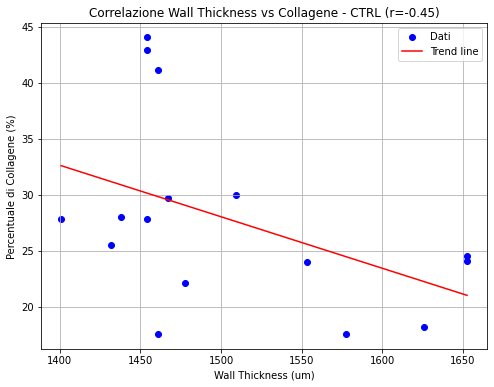

In [25]:
# Plot per CTRL
plot_wall_thickness_vs_collagen(
    CTRL_wall_thickness_interp,
    CTRL_perc_fibrosis_sum_dict,
    title="Correlazione Wall Thickness vs Collagene - CTRL"
)

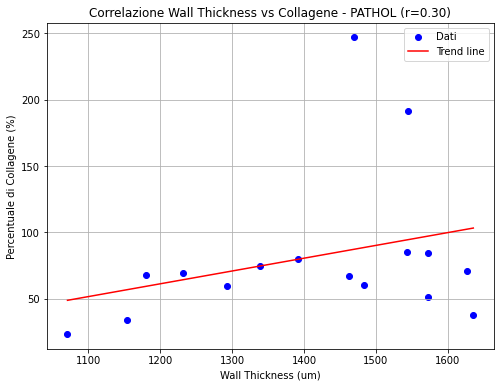

In [26]:
# Plot per PATHOL
plot_wall_thickness_vs_collagen(
    PATHOL_wall_thickness_interp,
    PATHOL_perc_fibrosis_sum_dict,
    title="Correlazione Wall Thickness vs Collagene - PATHOL"
)